# WAV Compression Benchmark: Raw vs FLAC — PyTorch vs VVTK C++ DataLoader

Compares five data-loading strategies for **variable-length sinusoid audio**:

| System | Storage | Loader |
|--------|---------|--------|
| **A**  | Raw `.wav` files on disk | PyTorch `DataLoader` + `soundfile` (baseline) |
| **B1** | VVTK shards (none / raw) | PyTorch `DataLoader` |
| **B2** | VVTK shards (FLAC) | PyTorch `DataLoader` + `soundfile` decode |
| **C1** | VVTK shards (none / raw) | `VVTKDataLoader` C++ |
| **C2** | VVTK shards (FLAC) | `VVTKDataLoader` C++ + `dr_flac` decode |

Audio is generated as deterministic sinusoids at random frequencies (200–4000 Hz), variable
duration 0.25–2 s, 16 kHz mono. Two summary tables: throughput and disk space.

In [13]:
import torch
import numpy as np
import os, time, shutil
import soundfile as sf
from vvtk_dataset import VVTKDataset, VVTKDataLoader

## Config

In [14]:
N           = 500
SR          = 16_000
MIN_DUR     = 0.25
MAX_DUR     = 2.0
MIN_AUDIO   = int(SR * MIN_DUR)
MAX_AUDIO   = int(SR * MAX_DUR)
BATCH_SIZE  = 64
NUM_WORKERS = 8
NUM_SHARDS  = 16
NUM_EPOCHS  = 2
DATA_DIR    = 'data'

MAX_PAD = MAX_AUDIO

## Step 1 — Generate sinusoid tones as `.wav` files

In [15]:
WAV_DIR = os.path.join(DATA_DIR, 'wav_files')
os.makedirs(WAV_DIR, exist_ok=True)

rng = np.random.default_rng(42)

print(f'Generating {N} sinusoid .wav files ({SR} Hz, {MIN_DUR}-{MAX_DUR}s) ...')
t0 = time.time()

sample_meta = []
for i in range(N):
    dur = rng.uniform(MIN_DUR, MAX_DUR)
    n_samples = int(SR * dur)
    freq = rng.uniform(200, 4000)
    t = np.arange(n_samples, dtype=np.float32) / SR
    waveform = (0.5 * np.sin(2 * np.pi * freq * t)).astype(np.float32)
    sf.write(os.path.join(WAV_DIR, f'{i:05d}.wav'), waveform, SR)
    sample_meta.append((n_samples, freq))
    if (i + 1) % 1_000 == 0:
        print(f'  {i+1}/{N} ({time.time()-t0:.1f}s)')

print(f'Done in {time.time()-t0:.1f}s')

Generating 500 sinusoid .wav files (16000 Hz, 0.25-2.0s) ...
Done in 16.7s


## Step 2 — Store into VVTK shards (raw + FLAC)

In [16]:
import glob

# ── VVTK shards with *no* compression (raw) ──
VVTK_NONE = os.path.join(DATA_DIR, 'shards_none', 'train')
os.makedirs(os.path.dirname(VVTK_NONE), exist_ok=True)

rng_none = np.random.default_rng(42)
print(f'Building VVTK shards (none) ...')
t0 = time.time()
with VVTKDataset(VVTK_NONE, mode='wb', num_shards=NUM_SHARDS,
                 compression=['none', 'none']) as ds:
    for i in range(N):
        audio, _ = sf.read(os.path.join(WAV_DIR, f'{i:05d}.wav'), dtype='float32')
        label = np.array([i], dtype=np.int64)
        ds.add(i, audio, label)
print(f'Done in {time.time()-t0:.1f}s')

# ── VVTK shards with FLAC compression ──
VVTK_FLAC = os.path.join(DATA_DIR, 'shards_flac', 'train')
os.makedirs(os.path.dirname(VVTK_FLAC), exist_ok=True)

print(f'Building VVTK shards (flac) ...')
t0 = time.time()
with VVTKDataset(VVTK_FLAC, mode='wb', num_shards=NUM_SHARDS,
                 compression=['flac', 'none'],
                 compression_args=[{'sample_rate': SR}, {}]) as ds:
    for i in range(N):
        audio, _ = sf.read(os.path.join(WAV_DIR, f'{i:05d}.wav'), dtype='float32')
        label = np.array([i], dtype=np.int64)
        ds.add(i, audio, label)
print(f'Done in {time.time()-t0:.1f}s')

# ── Measure sizes ──
def measure_size(pattern):
    return sum(os.path.getsize(f) for f in glob.glob(pattern))

def fmt_size(nbytes):
    if nbytes < 1024: return f'{nbytes} B'
    if nbytes < 1024**2: return f'{nbytes/1024:.1f} KB'
    if nbytes < 1024**3: return f'{nbytes/1024**2:.1f} MB'
    return f'{nbytes/1024**3:.2f} GB'

size_wav  = sum(os.path.getsize(os.path.join(WAV_DIR, f)) for f in os.listdir(WAV_DIR))
size_none = measure_size(f'{VVTK_NONE}.*.vvtk')
size_flac = measure_size(f'{VVTK_FLAC}.*.vvtk')

print(f'\nSizes:  wav={fmt_size(size_wav)}  vvtk_none={fmt_size(size_none)}  vvtk_flac={fmt_size(size_flac)}')
print(f'        flac/none = {size_flac/size_none:.2f}x   flac/wav = {size_flac/size_wav:.2f}x')

Building VVTK shards (none) ...
[VVTK] Saved dataset to data/shards_none/train
Done in 0.2s
Building VVTK shards (flac) ...


[VVTK] Saved dataset to data/shards_flac/train
Done in 0.5s

Sizes:  wav=16.9 MB  vvtk_none=33.8 MB  vvtk_flac=5.7 MB
        flac/none = 0.17x   flac/wav = 0.34x


## Step 3 — Define baseline PyTorch Dataset (reads .wav files)

In [17]:
class WavFileDataset(torch.utils.data.Dataset):
    """Reads individual .wav files from disk, pads to MAX_PAD."""
    def __init__(self, folder, n, max_pad):
        self.folder = folder
        self.n = n
        self.max_pad = max_pad

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        audio, _ = sf.read(os.path.join(self.folder, f'{idx:05d}.wav'), dtype='float32')
        audio_len = min(len(audio), self.max_pad)
        padded = np.zeros(self.max_pad, dtype=np.float32)
        padded[:audio_len] = audio[:audio_len]
        return (torch.from_numpy(padded),
                torch.tensor(audio_len, dtype=torch.int64))

## Run A — `.wav` files + PyTorch DataLoader (baseline)

In [18]:
wav_ds = WavFileDataset(WAV_DIR, N, MAX_PAD)
wav_loader = torch.utils.data.DataLoader(
    wav_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
    pin_memory=True, persistent_workers=True
)

print(f'Run A: .wav files + PyTorch DataLoader  ({len(wav_loader)} batches/epoch)')
rates_a = []
for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    for audio, audio_len in wav_loader:
        pass
    elapsed = time.time() - t0
    rate = N / elapsed
    rates_a.append(rate)
    print(f'  Epoch {epoch}: {elapsed:.2f}s  ({rate:.0f} samples/s)')

Run A: .wav files + PyTorch DataLoader  (8 batches/epoch)


  Epoch 1: 0.31s  (1628 samples/s)
  Epoch 2: 0.09s  (5679 samples/s)


## Run B1 — VVTK (none) + PyTorch DataLoader

In [19]:
ds_b1 = VVTKDataset(VVTK_NONE, mode='rb', compression=['none', 'none'],
                    fixed_shapes=[(MAX_PAD,), (1,)],
                    padding_values=[0.0, 0])
loader_b1 = torch.utils.data.DataLoader(
    ds_b1, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
    pin_memory=True, persistent_workers=True
)

print(f'Run B1: VVTK (none) + PyTorch DataLoader  ({len(loader_b1)} batches/epoch)')
rates_b1 = []
for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    for batch in loader_b1:
        pass
    elapsed = time.time() - t0
    rate = N / elapsed
    rates_b1.append(rate)
    print(f'  Epoch {epoch}: {elapsed:.2f}s  ({rate:.0f} samples/s)')

Run B1: VVTK (none) + PyTorch DataLoader  (8 batches/epoch)
  Epoch 1: 0.31s  (1635 samples/s)
  Epoch 2: 0.07s  (7675 samples/s)


## Run B2 — VVTK (FLAC) + PyTorch DataLoader

In [20]:
ds_b2 = VVTKDataset(VVTK_FLAC, mode='rb',
                    compression=['flac', 'none'],
                    compression_args=[{'sample_rate': SR}, {}],
                    fixed_shapes=[(MAX_PAD,), (1,)],
                    padding_values=[0.0, 0])
loader_b2 = torch.utils.data.DataLoader(
    ds_b2, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
    pin_memory=True, persistent_workers=True
)

print(f'Run B2: VVTK (flac) + PyTorch DataLoader  ({len(loader_b2)} batches/epoch)')
rates_b2 = []
for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    for batch in loader_b2:
        pass
    elapsed = time.time() - t0
    rate = N / elapsed
    rates_b2.append(rate)
    print(f'  Epoch {epoch}: {elapsed:.2f}s  ({rate:.0f} samples/s)')

Run B2: VVTK (flac) + PyTorch DataLoader  (8 batches/epoch)
  Epoch 1: 0.30s  (1649 samples/s)
  Epoch 2: 0.12s  (4247 samples/s)


## Run C1 — VVTK (none) + VVTKDataLoader C++

In [21]:
ds_c1 = VVTKDataset(VVTK_NONE, mode='rb', compression=['none', 'none'])
loader_c1 = VVTKDataLoader(
    ds_c1,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    ring_size=4,
    shapes=[(MAX_PAD,), (1,)],
    dtypes=[torch.float32, torch.int64],
    padding_values=[0.0, 0],
    shuffle=True
)

print(f'Run C1: VVTK (none) + VVTKDataLoader C++  ({len(loader_c1)} batches/epoch)')
rates_c1 = []
for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    for batch in loader_c1:
        pass
    elapsed = time.time() - t0
    rate = N / elapsed
    rates_c1.append(rate)
    print(f'  Epoch {epoch}: {elapsed:.2f}s  ({rate:.0f} samples/s)')

[VVTKLoader] Building index map...
[VVTKLoader] Ready in 0.00s
Run C1: VVTK (none) + VVTKDataLoader C++  (7 batches/epoch)
  Epoch 1: 0.05s  (10112 samples/s)
  Epoch 2: 0.01s  (40560 samples/s)


## Run C2 — VVTK (FLAC) + VVTKDataLoader C++ (dr_flac)

In [22]:
ds_c2 = VVTKDataset(VVTK_FLAC, mode='rb',
                    compression=['flac', 'none'],
                    compression_args=[{'sample_rate': SR}, {}])
loader_c2 = VVTKDataLoader(
    ds_c2,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    ring_size=4,
    shapes=[(MAX_PAD,), (1,)],
    dtypes=[torch.float32, torch.int64],
    padding_values=[0.0, 0],
    shuffle=True
)

print(f'Run C2: VVTK (flac) + VVTKDataLoader C++  ({len(loader_c2)} batches/epoch)')
rates_c2 = []
for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    for batch in loader_c2:
        pass
    elapsed = time.time() - t0
    rate = N / elapsed
    rates_c2.append(rate)
    print(f'  Epoch {epoch}: {elapsed:.2f}s  ({rate:.0f} samples/s)')

[VVTKLoader] Building index map...
[VVTKLoader] Ready in 0.00s
Run C2: VVTK (flac) + VVTKDataLoader C++  (7 batches/epoch)


  Epoch 1: 0.18s  (2795 samples/s)
  Epoch 2: 0.12s  (4123 samples/s)


## Summary — Throughput & Storage

In [23]:
avg_a  = np.mean(rates_a)
avg_b1 = np.mean(rates_b1)
avg_b2 = np.mean(rates_b2)
avg_c1 = np.mean(rates_c1)
avg_c2 = np.mean(rates_c2)

W = 90

# ── Throughput table ──
print('=' * W)
print('  Throughput Summary  (speedup vs A = .wav + Torch)')
print('=' * W)
print(f'  {"System":<40} {"rate":>10} {"speedup":>8}')
print(f'  {"─"*40} {"─"*10} {"─"*8}')
print(f'  {"A.  .wav + Torch DL (baseline)":<40} {avg_a:>8.0f}/s {"1.00x":>8}')
print(f'  {"B1. VVTK (none) + Torch DL":<40} {avg_b1:>8.0f}/s {avg_b1/avg_a:>7.2f}x')
print(f'  {"B2. VVTK (flac) + Torch DL":<40} {avg_b2:>8.0f}/s {avg_b2/avg_a:>7.2f}x')
print(f'  {"C1. VVTK (none) + VVTK C++ DL":<40} {avg_c1:>8.0f}/s {avg_c1/avg_a:>7.2f}x')
print(f'  {"C2. VVTK (flac) + VVTK C++ DL (dr_flac)":<40} {avg_c2:>8.0f}/s {avg_c2/avg_a:>7.2f}x')
print('=' * W)

# ── Storage table ──
print()
print('=' * W)
print('  Storage Summary')
print('=' * W)
print(f'  {"Format":<20} {"Size":>12} {"vs wav":>10} {"vs none":>10}')
print(f'  {"─"*20} {"─"*12} {"─"*10} {"─"*10}')
print(f'  {".wav files":<20} {fmt_size(size_wav):>12} {"1.00x":>10} {"":>10}')
print(f'  {"VVTK (none)":<20} {fmt_size(size_none):>12} {size_none/size_wav:>9.2f}x {"1.00x":>10}')
print(f'  {"VVTK (flac)":<20} {fmt_size(size_flac):>12} {size_flac/size_wav:>9.2f}x {size_flac/size_none:>9.2f}x')
print('=' * W)

  Throughput Summary  (speedup vs A = .wav + Torch)
  System                                         rate  speedup
  ──────────────────────────────────────── ────────── ────────
  A.  .wav + Torch DL (baseline)               3654/s    1.00x
  B1. VVTK (none) + Torch DL                   4655/s    1.27x
  B2. VVTK (flac) + Torch DL                   2948/s    0.81x
  C1. VVTK (none) + VVTK C++ DL               25336/s    6.93x
  C2. VVTK (flac) + VVTK C++ DL (dr_flac)      3459/s    0.95x

  Storage Summary
  Format                       Size     vs wav    vs none
  ──────────────────── ──────────── ────────── ──────────
  .wav files                16.9 MB      1.00x           
  VVTK (none)               33.8 MB      2.00x      1.00x
  VVTK (flac)                5.7 MB      0.34x      0.17x


## Visualise first batch

Audio batch shape: torch.Size([64, 32000])


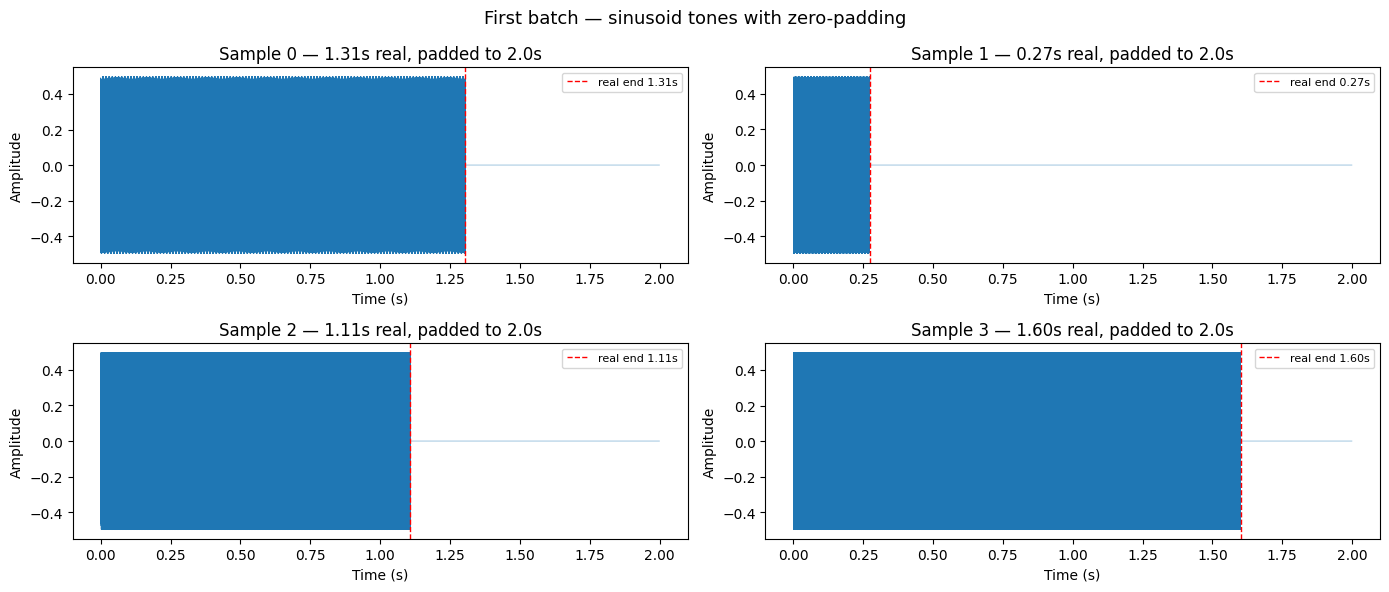

In [24]:
import matplotlib.pyplot as plt

batch_iter = iter(wav_loader)
audio_b, len_b = next(batch_iter)
print(f'Audio batch shape: {audio_b.shape}')

fig, axes = plt.subplots(2, 2, figsize=(14, 6))
for ax_idx, ax in enumerate(axes.flat):
    samples = audio_b[ax_idx].numpy()
    length = len_b[ax_idx].item()
    t_full = np.arange(MAX_PAD) / SR
    ax.plot(t_full, samples, linewidth=0.3, color='tab:blue')
    ax.axvline(x=length / SR, color='red', linestyle='--', linewidth=1,
               label=f'real end {length/SR:.2f}s')
    ax.set_title(f'Sample {ax_idx} — {length/SR:.2f}s real, padded to {MAX_PAD/SR:.1f}s')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')
    ax.legend(loc='upper right', fontsize=8)
fig.suptitle('First batch — sinusoid tones with zero-padding', fontsize=13)
plt.tight_layout()
plt.show()

## Cleanup

In [25]:
ds_b1.close()
ds_b2.close()
ds_c1.close()
ds_c2.close()

shutil.rmtree(DATA_DIR, ignore_errors=True)
print('Cleaned up.')

Cleaned up.
